# 03 — Mark activity (community-smoothed)

Classify whether cells are “active” for genomic bins using:

1. Random equal-ish partitions of the knn graph (not stable Leiden)
2. Community-smoothed activity $A = L D (L^{T} X_B)$
3. Per-feature background threshold → binary activity

Uses a **subset of variable bins** so the tutorial stays fast.


In [1]:
from pathlib import Path
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import sparscit as sc

sc.set_defaults(n_jobs=-1, figsize=(6, 5))

land = Path("../epigenetic_landscape_analysis_notebooks/demos/data") / "demo_landscape.h5ad"
emb = Path("../epigenetic_landscape_analysis_notebooks/demos/data") / "demo_embedded.h5ad"
if land.is_file():
    adata = ad.read_h5ad(land)
elif emb.is_file():
    adata = ad.read_h5ad(emb)
else:
    raise FileNotFoundError("Run notebook 01 (and ideally 02) first, or place cache h5ads in demos/data/")

if "distances" not in adata.obsp:
    sc.gr.knn(adata, "X_multi_spectral", n_neighbors=15)
print(adata.shape)


(4970, 21925)


In [2]:
# Top variable acet bins for a quick demo panel
var = np.asarray(
    adata.layers["acet"].power(2).mean(0) - np.square(adata.layers["acet"].mean(0))
).ravel()
n_features = 300
top = np.argsort(var)[-n_features:]
sub = adata[:, top].copy()
sub.obsp = adata.obsp.copy()
for k in list(adata.obsm.keys()):
    sub.obsm[k] = adata.obsm[k].copy()
print("panel", sub.shape)


panel (4970, 300)


In [3]:
# Many random graph partitions → membership matrix (cells × samples)
sc.adv.random_neighborhood_matrix(
    sub, n_clusters=40, sample_n=20, random_seed=0, obsp_key="connectivities"
)
print("random_matrix", sub.obsm["random_matrix"].shape)


random_matrix (4970, 20)


In [4]:
# Binarize layer inside LayerConfig via feature_active_threshold, then smooth
lc = sc.tl.make_layer_config(
    "acet",
    normalize_with_obs_counts=True,
    log_transform=True,
    feature_names=sub.var_names.to_numpy(),
    feature_active_threshold=0.0,  # presence after norm/log
)
sc.adv.neighborhood_activities(sub, lc, community_matrix="random_matrix")
print(sub.obsm["neighborhood_acet"].shape)


Info: Added to .obsm["neighborhood_acet"], .uns["neighborhood_acet_names"]
(4970, 300)


/home/aleksander-work/Dokument/work11/scit-package/src/sparscit/tools/_layers.py:202: RuntimeWarning: divide by zero encountered in divide
  _X = (diags(1 / d) @ _X)


In [11]:
# Binary activity from neighborhood scores (quantile background)
lc_n = sc.tl.make_layer_config(
    "neighborhood_acet",
    normalize_with_obs_counts=False,
    log_transform=False,
    in_obsm=True,
    feature_names=sub.uns["neighborhood_acet_names"],
)
# enrich_g=0.5 ~ sqrt-like background as in the methods (λ(x)=√(1+x)-1 family)
sc.adv.classify_enrichment(sub, lc_n, enrich_a=0.0, enrich_b=2.5, enrich_g=0.5, q=0.2)
B = sub.obsm["neighborhood_acet_active"]
breadth = np.asarray(B.sum(axis=1)).ravel()
sub.obs["mark_breadth"] = breadth
print("mean breadth", breadth.mean(), "nnz", B.nnz)


Info: Added to .obsm["neighborhood_acet_active"]
mean breadth 196.49034205231388 nnz 976557


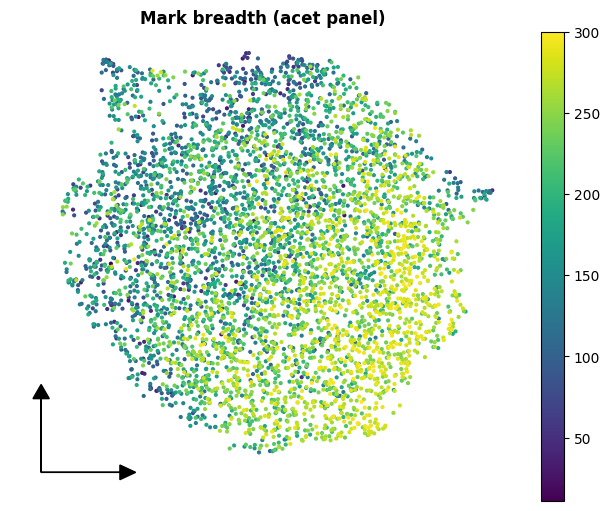

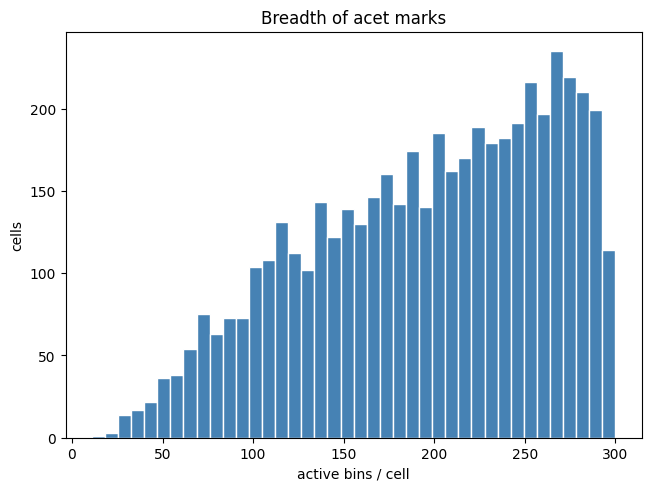

In [12]:
if "X_umap" in sub.obsm:
    sc.pl.embedding2d(sub, "X_umap", "mark_breadth", size=4, title="Mark breadth (acet panel)")
elif "X_landscape" in sub.obsm:
    sc.pl.embedding2d(sub, "X_landscape", "mark_breadth", size=4, title="Mark breadth (acet panel)")
plt.show()

plt.hist(breadth, bins=40, color="steelblue", edgecolor="white")
plt.xlabel("active bins / cell"); plt.ylabel("cells"); plt.title("Breadth of acet marks")
plt.show()
